# Multi-particle 2D Gravity

Simulating 5 particles interacting via the Poisson field equation $\nabla^2 \phi = \rho$.

In 2D this gives Newtonian gravity with $F \propto 1/r$. Unlike the 2-body `gravity_example`, here all 5 particles are dynamical

In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from physchool.worlds.field_sampler import FieldSampler
from physchool.env import _run_single_experiment, WorldConfig

%matplotlib inline
plt.rcParams.update({'font.size': 13})

## Setup: 5 particles in a pentagon

Place 5 unit-mass particles on the vertices of a regular pentagon (radius 4) with small tangential velocities so they orbit the common center of mass.

In [2]:
n_particles = 5
radius = 4.0
domain = 50.0
center = domain / 2
grid_size = 128
dt = 0.005

ops = [{'type': 'laplacian', 'params': {'strength': 1.0}}]

angles = np.linspace(0, 2 * np.pi, n_particles, endpoint=False)
positions = np.stack([center + radius * np.cos(angles),
                      center + radius * np.sin(angles)], axis=1)
masses = np.ones(n_particles)

# Estimate the net inward force on one vertex particle from the other 4.
# For 2D Poisson, F_pair = m1*m2 / (2*pi*r).
# Sum |F| contributions from the other 4 particles projected radially inward.
F_net_radial = 0.0
for i in range(1, n_particles):
    sep = 2 * radius * np.sin(i * np.pi / n_particles)
    F_mag = 1.0 / (2 * np.pi * sep)
    angle_between = i * 2 * np.pi / n_particles
    radial_component = -np.cos(np.pi - angle_between / 2)
    F_net_radial += F_mag * abs(radial_component)

# Centripetal balance: F_net = m * v^2 / R
v_circ = np.sqrt(F_net_radial * radius)
print(f"Estimated circular velocity: {v_circ:.4f}")

velocities = np.zeros((n_particles, 2))
for i in range(n_particles):
    tangent = np.array([-np.sin(angles[i]), np.cos(angles[i])])
    velocities[i] = v_circ * tangent

print(f"Particle positions (centered):\n{positions - center}")
print(f"Particle velocities:\n{velocities}")

Estimated circular velocity: 0.5204
Particle positions (centered):
[[ 4.          0.        ]
 [ 1.23606798  3.80422607]
 [-3.23606798  2.35114101]
 [-3.23606798 -2.35114101]
 [ 1.23606798 -3.80422607]]
Particle velocities:
[[-0.          0.52035619]
 [-0.49488814  0.16079891]
 [-0.30585769 -0.420977  ]
 [ 0.30585769 -0.420977  ]
 [ 0.49488814  0.16079891]]


## Measure initial forces

Before running the full trajectory, check that forces on all 5 particles are sensible:
- All forces should point inward (toward the center of mass)
- By symmetry, all force magnitudes should be approximately equal
- Newton's 3rd law: the total net force should be ~0

In [3]:
sim = FieldSampler(
    particle_inertia=masses, particle_source=masses, particle_force=masses,
    initial_positions=positions.copy(), initial_velocities=velocities.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_size, grid_size), domain_size=domain,
    operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
    source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
)

forces = sim.step()

print("Force magnitudes:")
for i in range(n_particles):
    fmag = float(jnp.sqrt(jnp.sum(forces[i]**2)))
    displacement = sim.positions[i] - center
    radial_dir = displacement / np.linalg.norm(displacement)
    f_radial = float(jnp.dot(forces[i], radial_dir))
    print(f"  Particle {i}: |F| = {fmag:.6f},  radial component = {f_radial:.6f} {'(inward)' if f_radial < 0 else '(OUTWARD!)'}")

net_force = np.asarray(jnp.sum(forces, axis=0))
print(f"\nNet force (should be ~0): [{net_force[0]:.2e}, {net_force[1]:.2e}]")
print(f"|Net force| / |F_0| = {np.linalg.norm(net_force) / float(jnp.sqrt(jnp.sum(forces[0]**2))):.2e}")

Force magnitudes:
  Particle 0: |F| = 0.075521,  radial component = -0.075521 (inward)
  Particle 1: |F| = 0.075612,  radial component = -0.075611 (inward)
  Particle 2: |F| = 0.075538,  radial component = -0.075538 (inward)
  Particle 3: |F| = 0.075538,  radial component = -0.075538 (inward)
  Particle 4: |F| = 0.075612,  radial component = -0.075612 (inward)

Net force (should be ~0): [-2.08e-17, -1.39e-17]
|Net force| / |F_0| = 3.31e-16


## Run the 5-body orbit

Evolve the system for many timesteps and record all trajectories. We also track total momentum and kinetic energy to check conservation.

In [4]:
n_steps = 4000

sim = FieldSampler(
    particle_inertia=masses, particle_source=masses, particle_force=masses,
    initial_positions=positions.copy(), initial_velocities=velocities.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_size, grid_size), domain_size=domain,
    operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
    source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
)

traj = np.zeros((n_steps + 1, n_particles, 2))
vel_hist = np.zeros((n_steps + 1, n_particles, 2))
traj[0] = sim.positions.copy()
vel_hist[0] = sim.velocities.copy()

momenta = []
kinetic_energies = []

for step in range(n_steps):
    sim.step()
    traj[step + 1] = sim.positions.copy()
    vel_hist[step + 1] = sim.velocities.copy()

    if step % 50 == 0:
        p_total = np.sum(masses[:, None] * sim.velocities, axis=0)
        ke = 0.5 * np.sum(masses[:, None] * sim.velocities**2)
        momenta.append(p_total.copy())
        kinetic_energies.append(ke)

momenta = np.array(momenta)
kinetic_energies = np.array(kinetic_energies)

traj_centered = traj - center

print(f"Simulation complete: {n_steps} steps, dt={dt}, T_final={n_steps*dt:.1f}")

Simulation complete: 4000 steps, dt=0.005, T_final=20.0


## Plot trajectories

Left: all 5 particle trajectories in the center-of-mass frame.
Right: separation of each particle from the center vs time (should oscillate if the orbit is quasi-stable).

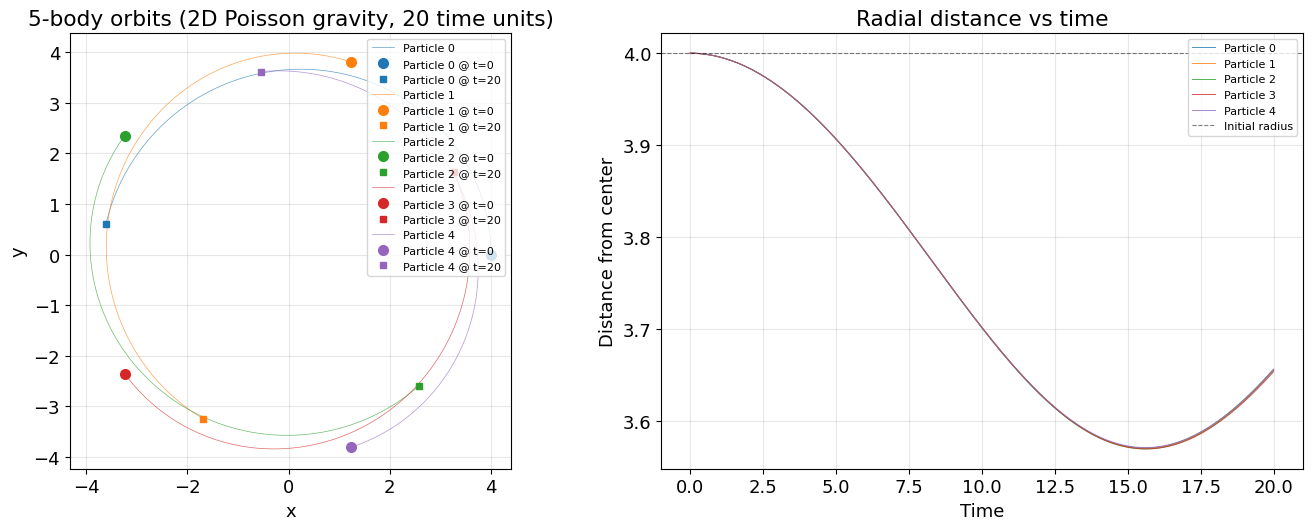

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

colors = plt.cm.tab10(np.arange(n_particles))
times = np.arange(n_steps + 1) * dt

# Left: 2D trajectories
ax = axes[0]
for i in range(n_particles):
    ax.plot(traj_centered[:, i, 0], traj_centered[:, i, 1],
            '-', lw=0.5, alpha=0.7, color=colors[i], label=f'Particle {i}')
    ax.plot(traj_centered[0, i, 0], traj_centered[0, i, 1],
            'o', ms=7, color=colors[i], zorder=5, label=f'Particle {i} @ t=0')
    ax.plot(traj_centered[-1, i, 0], traj_centered[-1, i, 1],
            's', ms=5, color=colors[i], zorder=5, label=f'Particle {i} @ t={n_steps*dt:.0f}')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'5-body orbits (2D Poisson gravity, {n_steps*dt:.0f} time units)')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Right: radius vs time
ax = axes[1]
for i in range(n_particles):
    radii = np.linalg.norm(traj_centered[:, i, :], axis=1)
    ax.plot(times, radii, '-', lw=0.7, alpha=0.8, color=colors[i], label=f'Particle {i}')
ax.axhline(radius, color='k', ls='--', lw=0.8, alpha=0.5, label='Initial radius')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from center')
ax.set_title('Radial distance vs time')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Conservation checks

Momentum should be conserved (Newton's 3rd law via CIC symmetry). Kinetic energy will oscillate but should not drift secularly.

Initial |p| = 0.000000
Final   |p| = 0.000000
Drift   |dp| = 4.19e-15
KE fractional drift: 18.08%


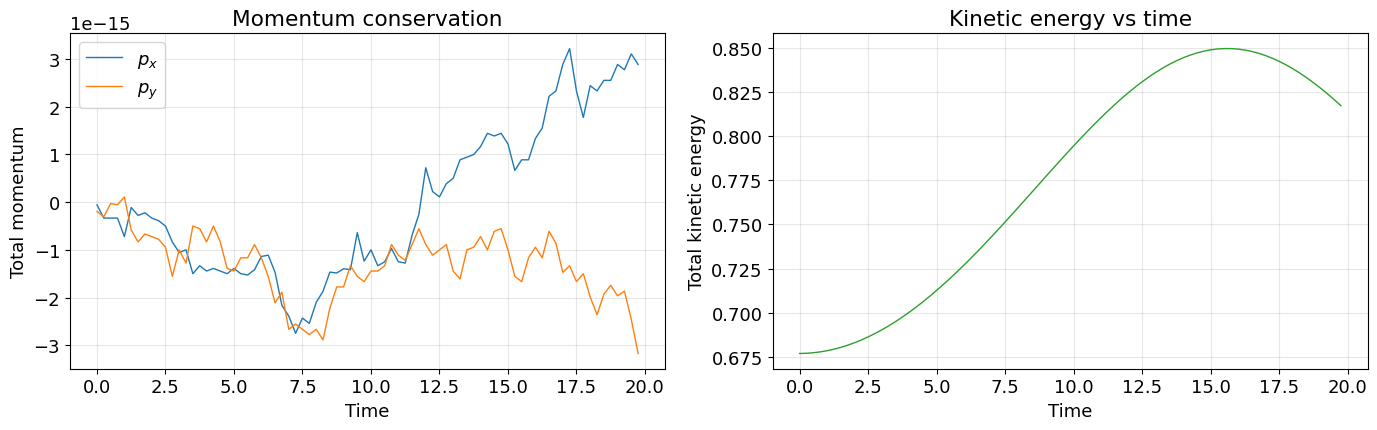

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sample_times = np.arange(len(momenta)) * 50 * dt

# Left: momentum components
ax = axes[0]
ax.plot(sample_times, momenta[:, 0], '-', lw=1, label=r'$p_x$')
ax.plot(sample_times, momenta[:, 1], '-', lw=1, label=r'$p_y$')
ax.set_xlabel('Time')
ax.set_ylabel('Total momentum')
ax.set_title('Momentum conservation')
ax.legend()
ax.grid(True, alpha=0.3)

p0_mag = np.linalg.norm(momenta[0])
p_final_mag = np.linalg.norm(momenta[-1])
drift = np.linalg.norm(momenta[-1] - momenta[0])
print(f"Initial |p| = {p0_mag:.6f}")
print(f"Final   |p| = {p_final_mag:.6f}")
print(f"Drift   |dp| = {drift:.2e}")

# Right: kinetic energy
ax = axes[1]
ax.plot(sample_times, kinetic_energies, '-', lw=1, color='C2')
ax.set_xlabel('Time')
ax.set_ylabel('Total kinetic energy')
ax.set_title('Kinetic energy vs time')
ax.grid(True, alpha=0.3)

ke_drift = abs(kinetic_energies[-1] - kinetic_energies[0]) / np.mean(kinetic_energies)
print(f"KE fractional drift: {ke_drift:.2%}")

plt.tight_layout()
plt.show()

## The field

Visualize the gravitational potential $\phi$ at the initial configuration and after evolution, with particle positions overlaid.

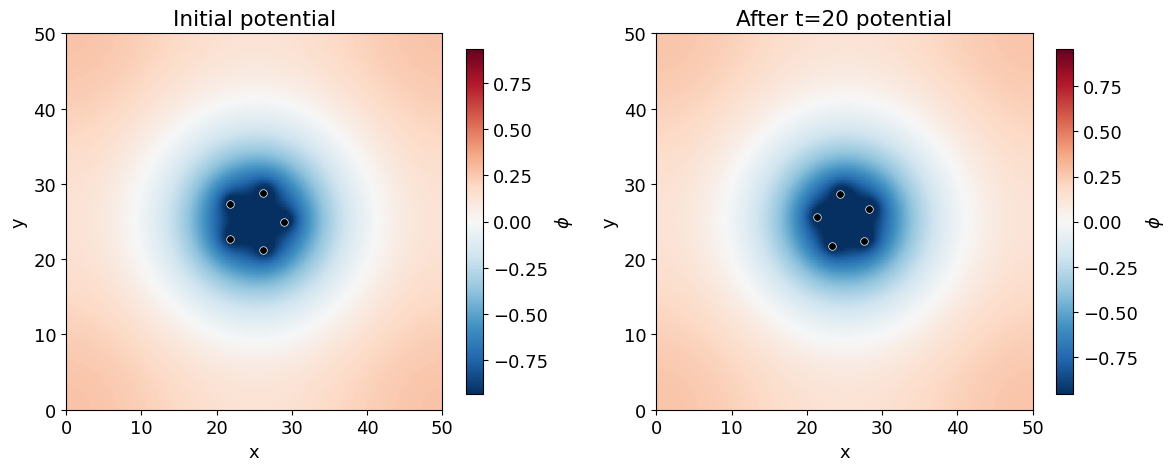

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

extent = [0, domain, 0, domain]

for ax, label, pos_snap in [
    (axes[0], 'Initial', traj[0]),
    (axes[1], f'After t={n_steps*dt:.0f}', traj[-1]),
]:
    snap_sim = FieldSampler(
        particle_inertia=masses, particle_source=masses, particle_force=masses,
        initial_positions=pos_snap.copy(),
        initial_velocities=np.zeros((n_particles, 2)),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(grid_size, grid_size), domain_size=domain,
        operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
        source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
    )
    snap_sim.step()
    field = np.asarray(snap_sim.field)

    vmax = np.percentile(np.abs(field), 98)
    im = ax.imshow(field.T, origin='lower', extent=extent, cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax)
    ax.scatter(pos_snap[:, 0], pos_snap[:, 1], c='k', s=30, zorder=5, edgecolors='w', linewidths=0.5)
    ax.set_title(f'{label} potential')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, shrink=0.8, label=r'$\phi$')

plt.tight_layout()
plt.show()

## Test via the environment wrapper

Run the same 5-particle configuration through `_run_single_experiment` (the same path an LLM agent would use) and verify it produces sensible output.

In [8]:
world = WorldConfig(
    operators=ops,
    temporal_order=0,
    domain_size=domain,
    grid_size=(grid_size, grid_size),
    dt=dt,
    periodic_boundaries=False,
)

positions_agent = positions - center

exp = {
    "particles": [
        {
            "property": float(masses[i]),
            "position": positions_agent[i].tolist(),
            "velocity": velocities[i].tolist(),
        }
        for i in range(n_particles)
    ],
    "duration": 2.0,
    "measurement_times": [0.0, 0.5, 1.0, 1.5, 2.0],
}

result = _run_single_experiment(exp, world)

if "error" in result:
    print(f"ERROR: {result['error']}")
else:
    print(f"Returned {len(result['positions'])} particle trajectories, "
          f"each with {len(result['positions'][0])} time snapshots.\n")
    for i in range(n_particles):
        print(f"Particle {i}:")
        for t_idx, t in enumerate(result['measurement_times']):
            pos = result['positions'][i][t_idx]
            vel = result['velocities'][i][t_idx]
            print(f"  t={t:.1f}:  pos=[{pos[0]:+.4f}, {pos[1]:+.4f}]  vel=[{vel[0]:+.4f}, {vel[1]:+.4f}]")

Returned 5 particle trajectories, each with 5 time snapshots.

Particle 0:
  t=0.0:  pos=[+4.0000, +0.0000]  vel=[-0.0000, +0.5204]
  t=0.5:  pos=[+3.9905, +0.2600]  vel=[-0.0378, +0.5191]
  t=1.0:  pos=[+3.9621, +0.5187]  vel=[-0.0754, +0.5155]
  t=1.5:  pos=[+3.9149, +0.7750]  vel=[-0.1127, +0.5093]
  t=2.0:  pos=[+3.8492, +1.0276]  vel=[-0.1497, +0.5008]
Particle 1:
  t=0.0:  pos=[+1.2361, +3.8042]  vel=[-0.4949, +0.1608]
  t=0.5:  pos=[+0.9859, +3.8755]  vel=[-0.5054, +0.1245]
  t=1.0:  pos=[+0.7310, +3.9284]  vel=[-0.5136, +0.0876]
  t=1.5:  pos=[+0.4727, +3.9628]  vel=[-0.5193, +0.0502]
  t=2.0:  pos=[+0.2121, +3.9784]  vel=[-0.5226, +0.0124]
Particle 2:
  t=0.0:  pos=[-3.2361, +2.3511]  vel=[-0.3059, -0.4210]
  t=0.5:  pos=[-3.3812, +2.1352]  vel=[-0.2746, -0.4422]
  t=1.0:  pos=[-3.5103, +1.9092]  vel=[-0.2420, -0.4613]
  t=1.5:  pos=[-3.6228, +1.6741]  vel=[-0.2082, -0.4783]
  t=2.0:  pos=[-3.7181, +1.4311]  vel=[-0.1733, -0.4931]
Particle 3:
  t=0.0:  pos=[-3.2361, -2.3511]  

Now test 100 particles

In [9]:
n_particles = 100
radius = 4.0
domain = 50.0
center = domain / 2
dt = 0.005

ops = [{'type': 'laplacian', 'params': {'strength': 1.0}}]

angles = np.linspace(0, 2 * np.pi, n_particles, endpoint=False)
positions = np.stack([center + radius * np.cos(angles),
                      center + radius * np.sin(angles)], axis=1)
masses = np.ones(n_particles)

# Use adaptive grid parameters for proper resolution at n=100
grid_size_tuple, src_smooth = FieldSampler.recommend_grid_params(
    positions, domain, spatial_dimensions=2)
grid_size = grid_size_tuple[0]
dx = domain / grid_size
chord = 2 * radius * np.sin(np.pi / n_particles)
print(f"Adaptive grid: {grid_size}x{grid_size}, dx={dx:.4f}, "
      f"chord/dx={chord/dx:.2f}, smoothing={src_smooth:.4f}")

# Correct radial projection: sin(i*pi/n), NOT cos(i*pi/n).
# Each particle contributes the same radial force 1/(4*pi*R),
# so F_net = (n-1)/(4*pi*R).
F_net_radial = (n_particles - 1) / (4 * np.pi * radius)
print(f"Theoretical F_net_radial = {F_net_radial:.6f}")

# Calibrate v_circ against actual simulation force (accounts for smoothing/grid)
sim_cal = FieldSampler(
    particle_inertia=masses, particle_source=masses, particle_force=masses,
    initial_positions=positions.copy(), initial_velocities=np.zeros((n_particles, 2)),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_size, grid_size), domain_size=domain,
    operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
    source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=src_smooth,
)
forces_cal = sim_cal.step()
f_rads = []
for i in range(n_particles):
    disp = sim_cal.positions[i] - center
    rhat = disp / np.linalg.norm(disp)
    f_rads.append(float(jnp.dot(forces_cal[i], rhat)))
F_sim = abs(np.mean(f_rads))
v_circ = np.sqrt(F_sim * radius)
print(f"Calibrated v_circ (sim F={F_sim:.6f}): {v_circ:.4f}")

velocities = np.zeros((n_particles, 2))
for i in range(n_particles):
    tangent = np.array([-np.sin(angles[i]), np.cos(angles[i])])
    velocities[i] = v_circ * tangent

print(f"\nFirst 3 positions (centered): {positions[:3] - center}")
print(f"First 3 velocities: {velocities[:3]}")

Adaptive grid: 598x598, dx=0.0836, chord/dx=3.01, smoothing=0.0836
Theoretical F_net_radial = 1.969542
Calibrated v_circ (sim F=1.887778): 2.7479

First 3 positions (centered): [[4.         0.        ]
 [3.99210691 0.25116208]
 [3.96845881 0.50133293]]
First 3 velocities: [[-0.          2.74792889]
 [-0.17254388  2.74250648]
 [-0.34440681  2.72626065]]


In [10]:
sim = FieldSampler(
    particle_inertia=masses, particle_source=masses, particle_force=masses,
    initial_positions=positions.copy(), initial_velocities=velocities.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_size, grid_size), domain_size=domain,
    operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
    source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=src_smooth,
)

forces = sim.step()

print("Force magnitudes (first 10 + summary):")
f_mags = []
f_rads_check = []
for i in range(n_particles):
    fmag = float(jnp.sqrt(jnp.sum(forces[i]**2)))
    displacement = sim.positions[i] - center
    radial_dir = displacement / np.linalg.norm(displacement)
    f_radial = float(jnp.dot(forces[i], radial_dir))
    f_mags.append(fmag)
    f_rads_check.append(f_radial)
    if i < 10:
        print(f"  Particle {i}: |F| = {fmag:.6f},  radial = {f_radial:.6f} {'(inward)' if f_radial < 0 else '(OUTWARD!)'}")

print(f"  ... ({n_particles} total)")
print(f"  |F| mean={np.mean(f_mags):.6f}, std={np.std(f_mags):.6f}")
print(f"  All inward: {all(r < 0 for r in f_rads_check)}")

net_force = np.asarray(jnp.sum(forces, axis=0))
print(f"\nNet force (should be ~0): [{net_force[0]:.2e}, {net_force[1]:.2e}]")

Force magnitudes (first 10 + summary):
  Particle 0: |F| = 1.883386,  radial = -1.883375 (inward)
  Particle 1: |F| = 1.884324,  radial = -1.884323 (inward)
  Particle 2: |F| = 1.883082,  radial = -1.882988 (inward)
  Particle 3: |F| = 1.891301,  radial = -1.891274 (inward)
  Particle 4: |F| = 1.880334,  radial = -1.880334 (inward)
  Particle 5: |F| = 1.889773,  radial = -1.889756 (inward)
  Particle 6: |F| = 1.892002,  radial = -1.891971 (inward)
  Particle 7: |F| = 1.890154,  radial = -1.890068 (inward)
  Particle 8: |F| = 1.888594,  radial = -1.888593 (inward)
  Particle 9: |F| = 1.881206,  radial = -1.881172 (inward)
  ... (100 total)
  |F| mean=1.887789, std=0.007292
  All inward: True

Net force (should be ~0): [-6.66e-15, 3.11e-15]


In [11]:
n_steps = 4000

sim = FieldSampler(
    particle_inertia=masses, particle_source=masses, particle_force=masses,
    initial_positions=positions.copy(), initial_velocities=velocities.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_size, grid_size), domain_size=domain,
    operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
    source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=src_smooth,
)

traj = np.zeros((n_steps + 1, n_particles, 2))
vel_hist = np.zeros((n_steps + 1, n_particles, 2))
traj[0] = sim.positions.copy()
vel_hist[0] = sim.velocities.copy()

momenta = []
kinetic_energies = []

for step in range(n_steps):
    sim.step()
    traj[step + 1] = sim.positions.copy()
    vel_hist[step + 1] = sim.velocities.copy()

    if step % 50 == 0:
        p_total = np.sum(masses[:, None] * sim.velocities, axis=0)
        ke = 0.5 * np.sum(masses[:, None] * sim.velocities**2)
        momenta.append(p_total.copy())
        kinetic_energies.append(ke)

momenta = np.array(momenta)
kinetic_energies = np.array(kinetic_energies)

traj_centered = traj - center

print(f"Simulation complete: {n_steps} steps, dt={dt}, T_final={n_steps*dt:.1f}")
radii_final = np.linalg.norm(traj_centered[-1], axis=1)
print(f"Final radii: mean={np.mean(radii_final):.3f}, std={np.std(radii_final):.3f}, "
      f"min={np.min(radii_final):.3f}, max={np.max(radii_final):.3f}")

Simulation complete: 4000 steps, dt=0.005, T_final=20.0
Final radii: mean=4.132, std=1.243, min=1.626, max=8.196


/tmp/ipykernel_2658674/1539335866.py:34: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


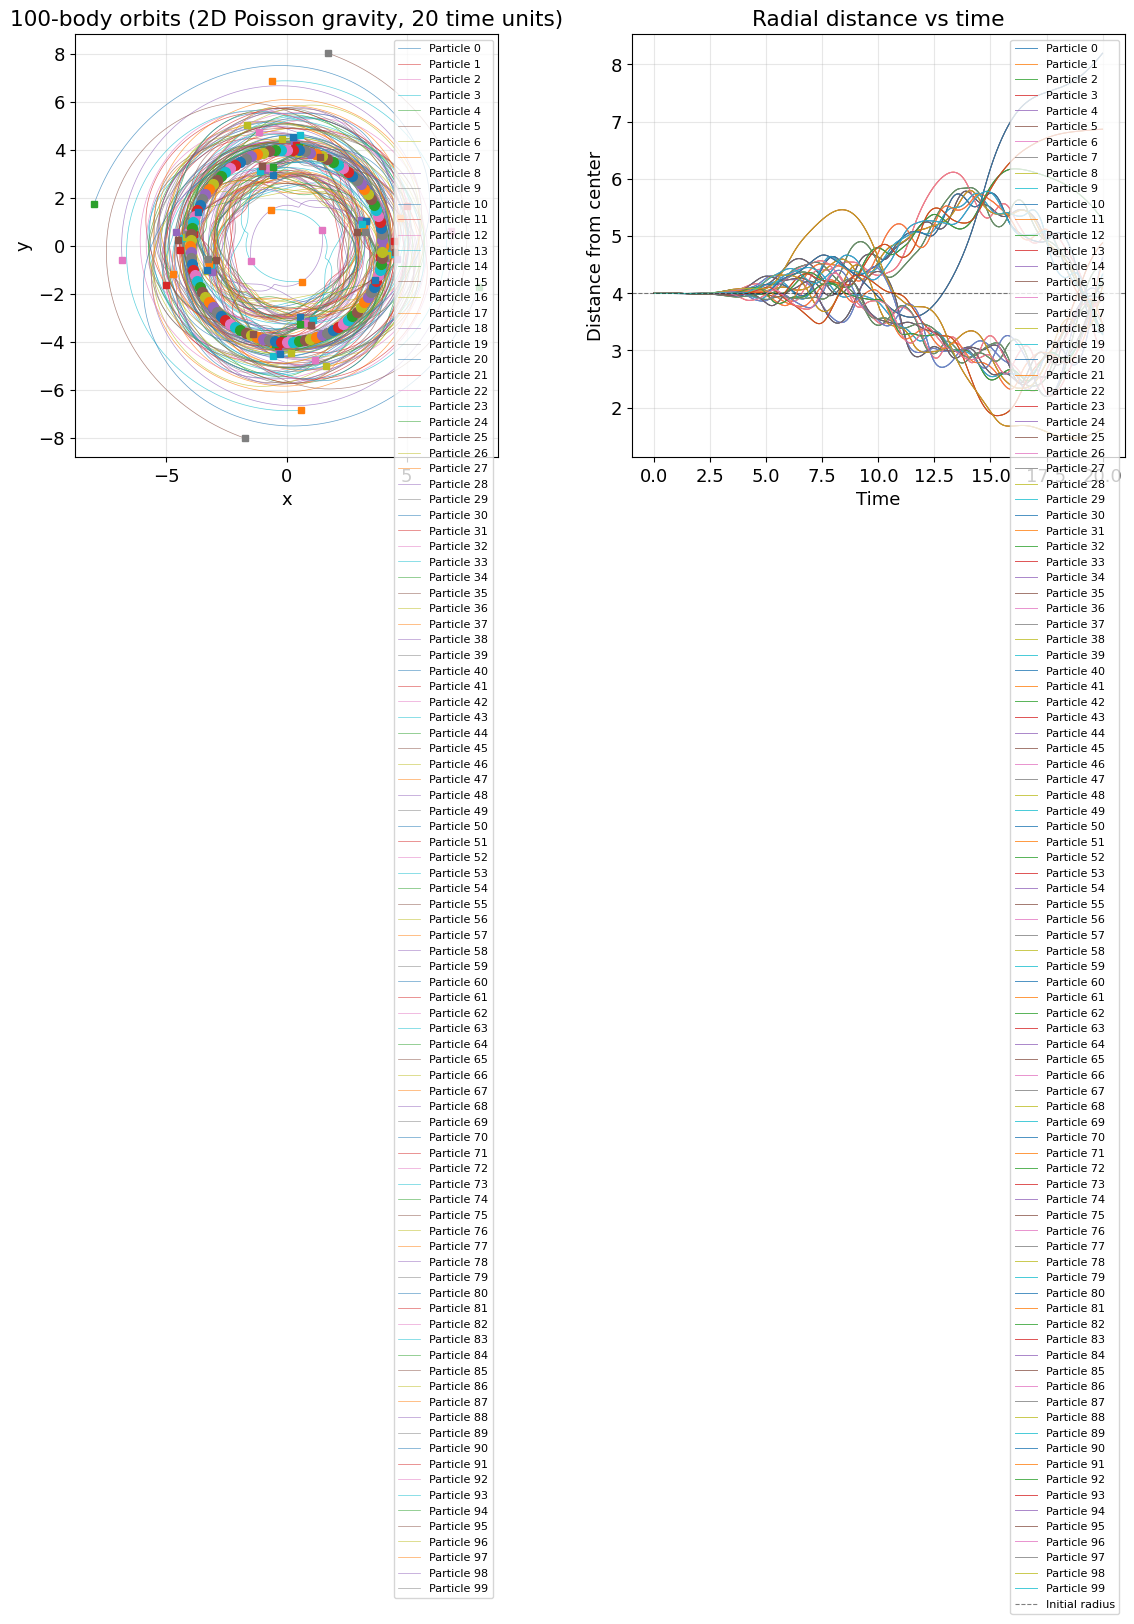

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# colors = plt.cm.tab20(np.arange(n_particles))
times = np.arange(n_steps + 1) * dt

# Left: 2D trajectories
ax = axes[0]
for i in range(n_particles):
    ax.plot(traj_centered[:, i, 0], traj_centered[:, i, 1],
            '-', lw=0.5, alpha=0.7, label=f'Particle {i}')
    ax.plot(traj_centered[0, i, 0], traj_centered[0, i, 1],
            'o', ms=7, zorder=5)
    ax.plot(traj_centered[-1, i, 0], traj_centered[-1, i, 1],
            's', ms=5, zorder=5)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'100-body orbits (2D Poisson gravity, {n_steps*dt:.0f} time units)')
ax.set_aspect('equal')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

# Right: radius vs time
ax = axes[1]
for i in range(n_particles):
    radii = np.linalg.norm(traj_centered[:, i, :], axis=1)
    ax.plot(times, radii, '-', lw=0.7, alpha=0.8, label=f'Particle {i}')
ax.axhline(radius, color='k', ls='--', lw=0.8, alpha=0.5, label='Initial radius')
ax.set_xlabel('Time')
ax.set_ylabel('Distance from center')
ax.set_title('Radial distance vs time')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Initial |p| = 0.000000
Final   |p| = 0.000000
Drift   |dp| = 9.90e-14
KE fractional drift: 0.37%


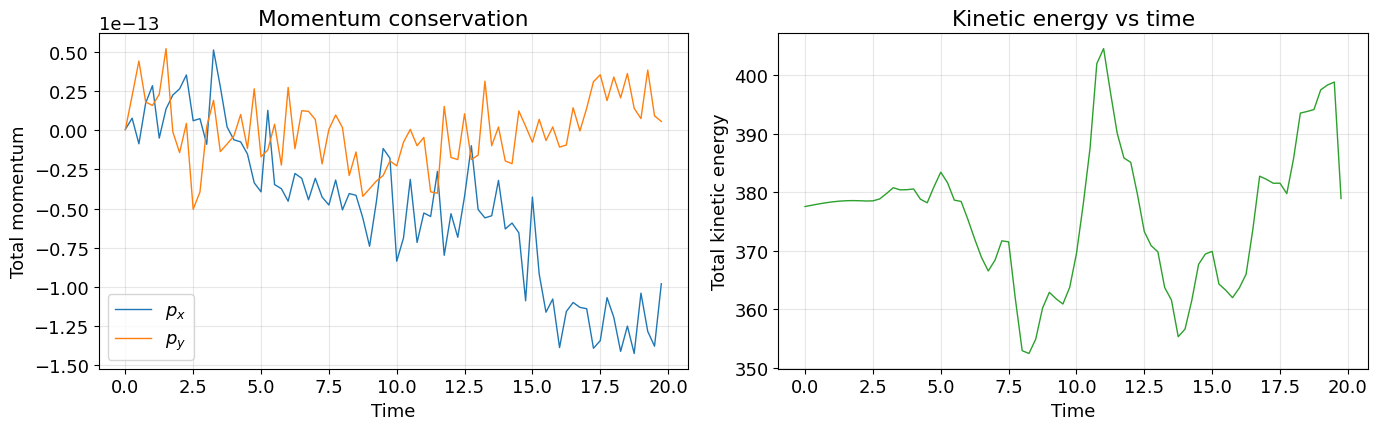

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sample_times = np.arange(len(momenta)) * 50 * dt

# Left: momentum components
ax = axes[0]
ax.plot(sample_times, momenta[:, 0], '-', lw=1, label=r'$p_x$')
ax.plot(sample_times, momenta[:, 1], '-', lw=1, label=r'$p_y$')
ax.set_xlabel('Time')
ax.set_ylabel('Total momentum')
ax.set_title('Momentum conservation')
ax.legend()
ax.grid(True, alpha=0.3)

p0_mag = np.linalg.norm(momenta[0])
p_final_mag = np.linalg.norm(momenta[-1])
drift = np.linalg.norm(momenta[-1] - momenta[0])
print(f"Initial |p| = {p0_mag:.6f}")
print(f"Final   |p| = {p_final_mag:.6f}")
print(f"Drift   |dp| = {drift:.2e}")

# Right: kinetic energy
ax = axes[1]
ax.plot(sample_times, kinetic_energies, '-', lw=1, color='C2')
ax.set_xlabel('Time')
ax.set_ylabel('Total kinetic energy')
ax.set_title('Kinetic energy vs time')
ax.grid(True, alpha=0.3)

ke_drift = abs(kinetic_energies[-1] - kinetic_energies[0]) / np.mean(kinetic_energies)
print(f"KE fractional drift: {ke_drift:.2%}")

plt.tight_layout()
plt.show()

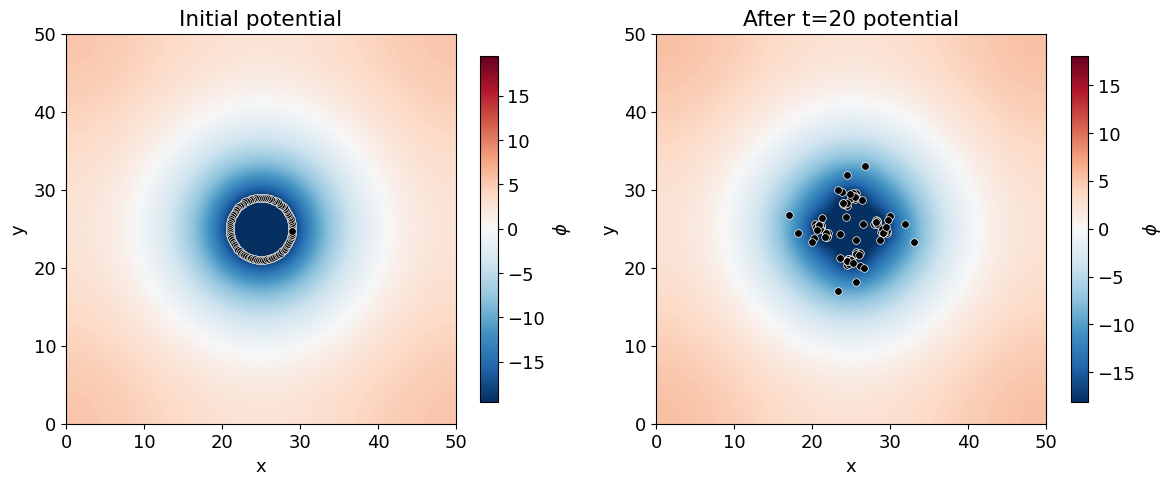

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

extent = [0, domain, 0, domain]

for ax, label, pos_snap in [
    (axes[0], 'Initial', traj[0]),
    (axes[1], f'After t={n_steps*dt:.0f}', traj[-1]),
]:
    snap_sim = FieldSampler(
        particle_inertia=masses, particle_source=masses, particle_force=masses,
        initial_positions=pos_snap.copy(),
        initial_velocities=np.zeros((n_particles, 2)),
        spatial_dimensions=2, temporal_order=0,
        grid_size=(grid_size, grid_size), domain_size=domain,
        operators=ops, n_particles=n_particles, force_law='gradient', dt=dt,
        source_coupling=masses, force_coupling=1.0, periodic_boundaries=False,
        source_smoothing=src_smooth,
    )
    snap_sim.step()
    field = np.asarray(snap_sim.field)

    vmax = np.percentile(np.abs(field), 98)
    im = ax.imshow(field.T, origin='lower', extent=extent, cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax)
    ax.scatter(pos_snap[:, 0], pos_snap[:, 1], c='k', s=30, zorder=5, edgecolors='w', linewidths=0.5)
    ax.set_title(f'{label} potential')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(im, ax=ax, shrink=0.8, label=r'$\phi$')

plt.tight_layout()
plt.show()

## 200-particle ring test

Verify that the simulation works at n=200 with adaptive grid parameters. The ring is physically unstable for large N, but particles should maintain approximate orbits for many orbital periods before instability grows — they should NOT fly off immediately.

n=200 grid: 512x512, dx=0.0977, chord/dx=1.29, smoothing=0.0977
Theory F=3.9590, sim F=3.7748, v_circ=3.8858

Done: 4000 steps, T=20.0
Final radii: mean=4.113, std=1.381, min=2.024, max=11.065


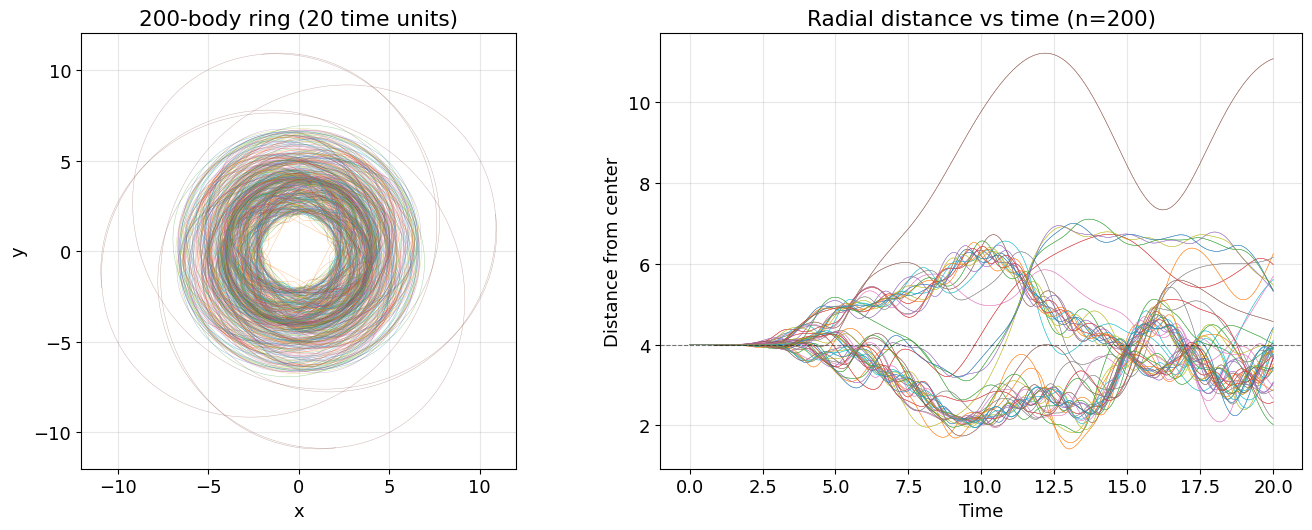

In [15]:
n_particles_200 = 200
radius_200 = 4.0
domain_200 = 50.0
center_200 = domain_200 / 2.0
dt_200 = 0.005

angles_200 = np.linspace(0, 2 * np.pi, n_particles_200, endpoint=False)
positions_200 = np.stack([center_200 + radius_200 * np.cos(angles_200),
                          center_200 + radius_200 * np.sin(angles_200)], axis=1)
masses_200 = np.ones(n_particles_200)

grid_200_tuple, smooth_200 = FieldSampler.recommend_grid_params(
    positions_200, domain_200, spatial_dimensions=2, max_grid_size=512)
grid_200 = grid_200_tuple[0]
chord_200 = 2 * radius_200 * np.sin(np.pi / n_particles_200)
print(f"n=200 grid: {grid_200}x{grid_200}, dx={domain_200/grid_200:.4f}, "
      f"chord/dx={chord_200/(domain_200/grid_200):.2f}, smoothing={smooth_200:.4f}")

# Calibrate v_circ
sim_cal_200 = FieldSampler(
    particle_inertia=masses_200, particle_source=masses_200, particle_force=masses_200,
    initial_positions=positions_200.copy(), initial_velocities=np.zeros((n_particles_200, 2)),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_200, grid_200), domain_size=domain_200,
    operators=ops, n_particles=n_particles_200, force_law='gradient', dt=dt_200,
    source_coupling=masses_200, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=smooth_200,
)
forces_200 = sim_cal_200.step()
f_rads_200 = []
for i in range(n_particles_200):
    disp = sim_cal_200.positions[i] - center_200
    rhat = disp / np.linalg.norm(disp)
    f_rads_200.append(float(jnp.dot(forces_200[i], rhat)))
F_sim_200 = abs(np.mean(f_rads_200))
v_circ_200 = np.sqrt(F_sim_200 * radius_200)
F_theory_200 = (n_particles_200 - 1) / (4 * np.pi * radius_200)
print(f"Theory F={F_theory_200:.4f}, sim F={F_sim_200:.4f}, v_circ={v_circ_200:.4f}")

velocities_200 = np.zeros((n_particles_200, 2))
for i in range(n_particles_200):
    tangent = np.array([-np.sin(angles_200[i]), np.cos(angles_200[i])])
    velocities_200[i] = v_circ_200 * tangent

n_steps_200 = 4000
sim_200 = FieldSampler(
    particle_inertia=masses_200, particle_source=masses_200, particle_force=masses_200,
    initial_positions=positions_200.copy(), initial_velocities=velocities_200.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_200, grid_200), domain_size=domain_200,
    operators=ops, n_particles=n_particles_200, force_law='gradient', dt=dt_200,
    source_coupling=masses_200, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=smooth_200,
)

traj_200 = np.zeros((n_steps_200 + 1, n_particles_200, 2))
traj_200[0] = sim_200.positions.copy()
for step in range(n_steps_200):
    sim_200.step()
    traj_200[step + 1] = sim_200.positions.copy()

traj_200_c = traj_200 - center_200
radii_200_final = np.linalg.norm(traj_200_c[-1], axis=1)
print(f"\nDone: {n_steps_200} steps, T={n_steps_200*dt_200:.1f}")
print(f"Final radii: mean={np.mean(radii_200_final):.3f}, std={np.std(radii_200_final):.3f}, "
      f"min={np.min(radii_200_final):.3f}, max={np.max(radii_200_final):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
times_200 = np.arange(n_steps_200 + 1) * dt_200
ax = axes[0]
for i in range(n_particles_200):
    ax.plot(traj_200_c[:, i, 0], traj_200_c[:, i, 1], '-', lw=0.3, alpha=0.5)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'200-body ring ({n_steps_200*dt_200:.0f} time units)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
ax = axes[1]
for i in range(n_particles_200):
    radii = np.linalg.norm(traj_200_c[:, i, :], axis=1)
    ax.plot(times_200, radii, '-', lw=0.3, alpha=0.5)
ax.axhline(radius_200, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Time'); ax.set_ylabel('Distance from center')
ax.set_title('Radial distance vs time (n=200)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Solar system tests

**Standard Laplacian** ($\nabla^2\phi = \rho$): 1 massive sun + 99 planets.
In 2D, $F \propto 1/r$ gives $v_{\rm circ} = \sqrt{M_\odot / 2\pi}$ (independent of $r$).

**Fractional Laplacian** ($(-\nabla^2)^\alpha \phi = \rho$): Force law $F \propto r^{2\alpha-3}$.
- $\alpha=1$: 2D gravity, $v_{\rm circ}$ constant
- $\alpha=3/4$: $v_{\rm circ} \propto r^{-1/4}$ (outer planets slower)
- $\alpha=1/2$: Kepler-like, $v_{\rm circ} \propto r^{-1/2}$

Solar system: 1 sun (M=100.0) + 99 planets (m=0.01)
Grid: 256x256, smoothing=0.5000
Done: 8000 steps, T=16.0


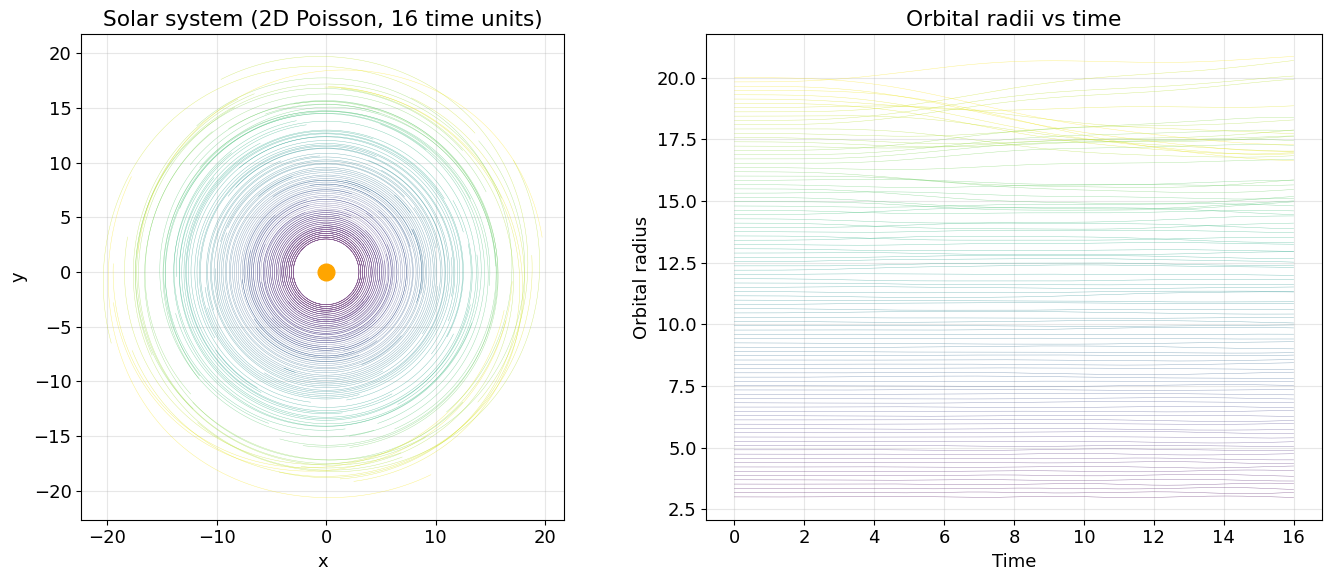


Orbit stability:
  Planet 0: r0=3.00, rf=2.98, drift=0.8%
  Planet 24: r0=7.16, rf=7.14, drift=0.4%
  Planet 49: r0=11.50, rf=11.51, drift=0.1%
  Planet 74: r0=15.84, rf=15.65, drift=1.2%
  Planet 98: r0=20.00, rf=17.30, drift=13.5%


In [16]:
rng = np.random.RandomState(42)
n_planets = 99
M_sun = 100.0
m_planet = 0.01
domain_ss = 60.0
center_ss = domain_ss / 2
dt_ss = 0.002
grid_ss = 256

ops_ss = [{'type': 'laplacian', 'params': {'strength': 1.0}}]

sun_pos = np.array([[center_ss, center_ss]])
radii_planets = np.linspace(3.0, 20.0, n_planets)
angle_planets = rng.uniform(0, 2 * np.pi, n_planets)
planet_pos = np.stack([center_ss + radii_planets * np.cos(angle_planets),
                       center_ss + radii_planets * np.sin(angle_planets)], axis=1)
positions_ss = np.vstack([sun_pos, planet_pos])
masses_ss = np.concatenate([[M_sun], np.full(n_planets, m_planet)])

smooth_ss = max(domain_ss / grid_ss, 0.5)

# Calibrate per-planet v_circ from simulation force
sim_ss_cal = FieldSampler(
    particle_inertia=masses_ss, particle_source=masses_ss, particle_force=masses_ss,
    initial_positions=positions_ss.copy(), initial_velocities=np.zeros((1+n_planets, 2)),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_ss, grid_ss), domain_size=domain_ss,
    operators=ops_ss, n_particles=1+n_planets, force_law='gradient', dt=dt_ss,
    source_coupling=masses_ss, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=smooth_ss,
)
forces_ss_cal = sim_ss_cal.step()

velocities_ss = np.zeros((1 + n_planets, 2))
for idx in range(n_planets):
    i = 1 + idx
    disp = sim_ss_cal.positions[i] - center_ss
    r = np.linalg.norm(disp)
    rhat = disp / r
    f_rad = abs(float(jnp.dot(forces_ss_cal[i], rhat)))
    v = np.sqrt(f_rad * r / m_planet)
    tangent = np.array([-np.sin(angle_planets[idx]), np.cos(angle_planets[idx])])
    velocities_ss[1 + idx] = v * tangent

print(f"Solar system: 1 sun (M={M_sun}) + {n_planets} planets (m={m_planet})")
print(f"Grid: {grid_ss}x{grid_ss}, smoothing={smooth_ss:.4f}")

# Evolve
n_steps_ss = 8000
sim_ss = FieldSampler(
    particle_inertia=masses_ss, particle_source=masses_ss, particle_force=masses_ss,
    initial_positions=positions_ss.copy(), initial_velocities=velocities_ss.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_ss, grid_ss), domain_size=domain_ss,
    operators=ops_ss, n_particles=1+n_planets, force_law='gradient', dt=dt_ss,
    source_coupling=masses_ss, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=smooth_ss,
)

traj_ss = np.zeros((n_steps_ss + 1, 1 + n_planets, 2))
traj_ss[0] = sim_ss.positions.copy()
for step in range(n_steps_ss):
    sim_ss.step()
    traj_ss[step + 1] = sim_ss.positions.copy()

traj_ss_c = traj_ss - center_ss
print(f"Done: {n_steps_ss} steps, T={n_steps_ss*dt_ss:.1f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax = axes[0]
ax.plot(0, 0, 'o', ms=12, color='orange', zorder=10, label='Sun')
colors_ss = plt.cm.viridis(np.linspace(0, 1, n_planets))
for idx in range(n_planets):
    i = 1 + idx
    ax.plot(traj_ss_c[:, i, 0], traj_ss_c[:, i, 1], '-', lw=0.3, alpha=0.6, color=colors_ss[idx])
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Solar system (2D Poisson, {n_steps_ss*dt_ss:.0f} time units)')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
times_ss = np.arange(n_steps_ss + 1) * dt_ss
for idx in range(n_planets):
    i = 1 + idx
    r = np.linalg.norm(traj_ss_c[:, i, :], axis=1)
    ax.plot(times_ss, r, '-', lw=0.3, alpha=0.6, color=colors_ss[idx])
ax.set_xlabel('Time'); ax.set_ylabel('Orbital radius')
ax.set_title('Orbital radii vs time')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOrbit stability:")
for idx in [0, 24, 49, 74, 98]:
    i = 1 + idx
    r0 = np.linalg.norm(traj_ss_c[0, i])
    rf = np.linalg.norm(traj_ss_c[-1, i])
    drift = abs(rf - r0) / r0
    print(f"  Planet {idx}: r0={r0:.2f}, rf={rf:.2f}, drift={drift:.1%}")

Fractional Laplacian alpha=0.75
v_circ power law: v ~ r^-0.304 (expected r^-0.250)
Done: 8000 steps, T=16.0


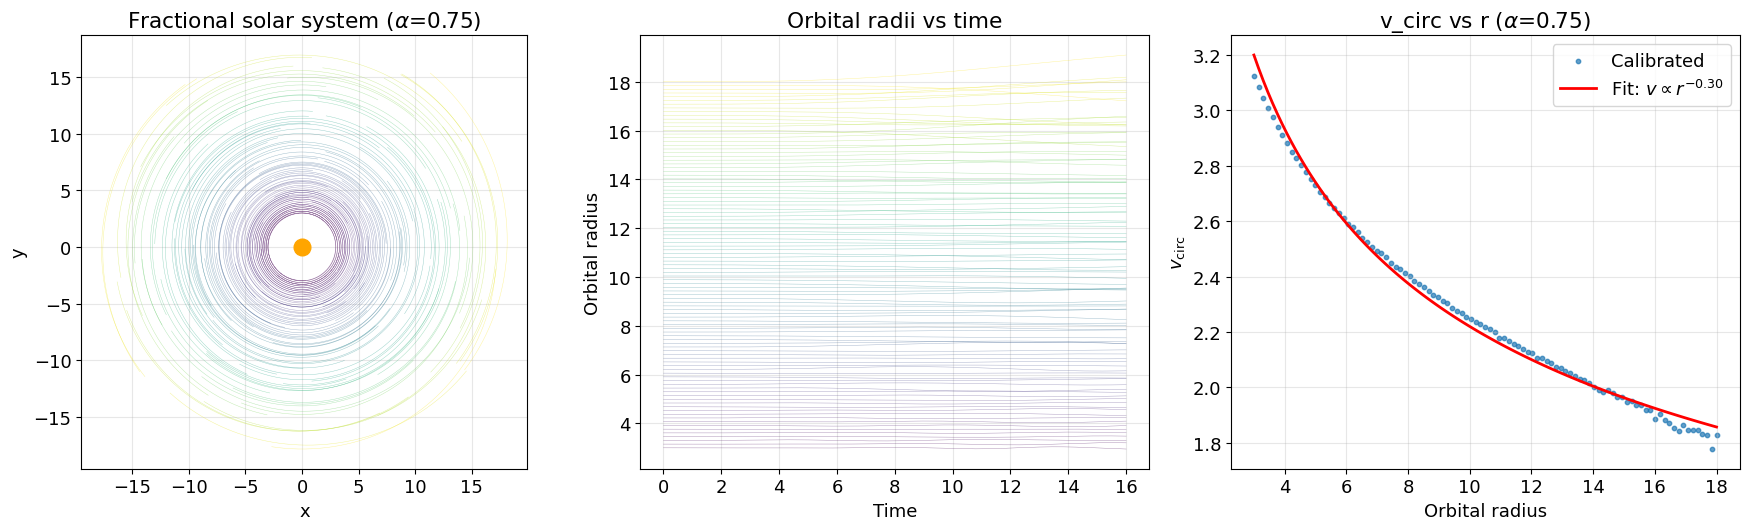


Orbit stability:
  Planet 0: r0=3.00, rf=2.95, drift=1.6%
  Planet 24: r0=6.67, rf=6.65, drift=0.3%
  Planet 49: r0=10.50, rf=10.28, drift=2.1%
  Planet 74: r0=14.33, rf=14.16, drift=1.2%
  Planet 98: r0=18.00, rf=19.10, drift=6.1%


In [17]:
alpha_frac = 0.75
domain_f = 60.0
center_f = domain_f / 2
dt_f = 0.002
grid_f = 256
n_planets_f = 99

ops_frac = [{'type': 'fractional_laplacian', 'params': {'strength': 1.0, 'alpha': alpha_frac}}]

sun_pos_f = np.array([[center_f, center_f]])
radii_f = np.linspace(3.0, 18.0, n_planets_f)
angles_f = rng.uniform(0, 2 * np.pi, n_planets_f)
planet_pos_f = np.stack([center_f + radii_f * np.cos(angles_f),
                          center_f + radii_f * np.sin(angles_f)], axis=1)
positions_f = np.vstack([sun_pos_f, planet_pos_f])
masses_f = np.concatenate([[M_sun], np.full(n_planets_f, m_planet)])
smooth_f = max(domain_f / grid_f, 0.5)

# Calibrate per-planet v_circ
sim_f_cal = FieldSampler(
    particle_inertia=masses_f, particle_source=masses_f, particle_force=masses_f,
    initial_positions=positions_f.copy(), initial_velocities=np.zeros((1+n_planets_f, 2)),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_f, grid_f), domain_size=domain_f,
    operators=ops_frac, n_particles=1+n_planets_f, force_law='gradient', dt=dt_f,
    source_coupling=masses_f, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=smooth_f,
)
forces_f_cal = sim_f_cal.step()

velocities_f = np.zeros((1 + n_planets_f, 2))
v_circs_f = []
for idx in range(n_planets_f):
    i = 1 + idx
    disp = sim_f_cal.positions[i] - center_f
    r = np.linalg.norm(disp)
    rhat = disp / r
    f_rad = abs(float(jnp.dot(forces_f_cal[i], rhat)))
    v = np.sqrt(f_rad * r / m_planet)
    v_circs_f.append(v)
    tangent = np.array([-np.sin(angles_f[idx]), np.cos(angles_f[idx])])
    velocities_f[1 + idx] = v * tangent

log_r = np.log(radii_f)
log_v = np.log(v_circs_f)
slope, intercept = np.polyfit(log_r, log_v, 1)
print(f"Fractional Laplacian alpha={alpha_frac}")
print(f"v_circ power law: v ~ r^{slope:.3f} (expected r^{alpha_frac-1:.3f})")

# Evolve
n_steps_f = 8000
sim_f = FieldSampler(
    particle_inertia=masses_f, particle_source=masses_f, particle_force=masses_f,
    initial_positions=positions_f.copy(), initial_velocities=velocities_f.copy(),
    spatial_dimensions=2, temporal_order=0,
    grid_size=(grid_f, grid_f), domain_size=domain_f,
    operators=ops_frac, n_particles=1+n_planets_f, force_law='gradient', dt=dt_f,
    source_coupling=masses_f, force_coupling=1.0, periodic_boundaries=False,
    source_smoothing=smooth_f,
)

traj_f = np.zeros((n_steps_f + 1, 1 + n_planets_f, 2))
traj_f[0] = sim_f.positions.copy()
for step in range(n_steps_f):
    sim_f.step()
    traj_f[step + 1] = sim_f.positions.copy()

traj_f_c = traj_f - center_f
print(f"Done: {n_steps_f} steps, T={n_steps_f*dt_f:.1f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
times_f = np.arange(n_steps_f + 1) * dt_f

ax = axes[0]
ax.plot(0, 0, 'o', ms=12, color='orange', zorder=10)
colors_f = plt.cm.viridis(np.linspace(0, 1, n_planets_f))
for idx in range(n_planets_f):
    i = 1 + idx
    ax.plot(traj_f_c[:, i, 0], traj_f_c[:, i, 1], '-', lw=0.3, alpha=0.5, color=colors_f[idx])
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(f'Fractional solar system ($\\alpha$={alpha_frac})')
ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

ax = axes[1]
for idx in range(n_planets_f):
    i = 1 + idx
    r = np.linalg.norm(traj_f_c[:, i, :], axis=1)
    ax.plot(times_f, r, '-', lw=0.3, alpha=0.5, color=colors_f[idx])
ax.set_xlabel('Time'); ax.set_ylabel('Orbital radius')
ax.set_title('Orbital radii vs time')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.scatter(radii_f, v_circs_f, s=10, alpha=0.7, label='Calibrated')
r_fit = np.linspace(radii_f.min(), radii_f.max(), 100)
ax.plot(r_fit, np.exp(intercept) * r_fit**slope, 'r-', lw=2,
        label=f'Fit: $v \\propto r^{{{slope:.2f}}}$')
ax.set_xlabel('Orbital radius'); ax.set_ylabel('$v_{\\rm circ}$')
ax.set_title(f'v_circ vs r ($\\alpha$={alpha_frac})')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nOrbit stability:")
for idx in [0, 24, 49, 74, 98]:
    i = 1 + idx
    r0 = np.linalg.norm(traj_f_c[0, i])
    rf = np.linalg.norm(traj_f_c[-1, i])
    drift = abs(rf - r0) / r0
    print(f"  Planet {idx}: r0={r0:.2f}, rf={rf:.2f}, drift={drift:.1%}")